# Task 5: Personal Loan Acceptance Prediction
## DevelopersHub Corporation - Data Science Internship

### Problem Statement:
The goal of this project is to predict whether a bank customer
will accept a personal loan offer or not, based on their
demographic and financial information.

### Dataset:
Bank Marketing Dataset - 11,162 rows, 17 columns

### Target Variable:
deposit - Yes (loan accept) / No (loan reject)

In [3]:
# Importing necessary libraries

import pandas as pd                  # Data loading and manipulation
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Advanced visualization

from sklearn.preprocessing import LabelEncoder          # Encoding categorical data
from sklearn.model_selection import train_test_split    # Splitting data
from sklearn.linear_model import LogisticRegression     # Model 1
from sklearn.tree import DecisionTreeClassifier         # Model 2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation

import warnings
warnings.filterwarnings('ignore')    # Hide unnecessary warnings

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Loading the dataset

df = pd.read_csv('bank.csv')

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

In [ ]:
# Data Exploration

# Data types of each column
print("=== Data Types ===")
print(df.dtypes)

# Statistical summary
print("\n=== Statistical Summary ===")
print(df.describe())

# Missing values check
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Target column distribution
print("\n=== Target Column (deposit) ===")
print(df['deposit'].value_counts())

In [ ]:
# EDA - Exploratory Data Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16)

# Graph 1 - Age Distribution
sns.histplot(df['age'], bins=30, kde=True, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Graph 2 - Deposit (Target) Count
sns.countplot(x='deposit', data=df, palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Loan Accept vs Reject')
axes[0,1].set_xlabel('Deposit')
axes[0,1].set_ylabel('Count')

# Graph 3 - Job vs Deposit
sns.countplot(x='job', hue='deposit', data=df, palette='Set1', ax=axes[1,0])
axes[1,0].set_title('Job Type vs Deposit')
axes[1,0].set_xlabel('Job')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)

# Graph 4 - Marital Status vs Deposit
sns.countplot(x='marital', hue='deposit', data=df, palette='Set3', ax=axes[1,1])
axes[1,1].set_title('Marital Status vs Deposit')
axes[1,1].set_xlabel('Marital Status')
axes[1,1].set_ylabel('Count')

plt.tight_layout()

# ✅ Graph folder mein save karo
plt.savefig('eda_graphs.png', dpi=150, bbox_inches='tight')
print("Graph saved!")

plt.show()

In [ ]:
# Data Encoding - Categorical columns ko numbers mein convert karna

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Copy of original dataframe
df_encoded = df.copy()

# Encoding all categorical columns
categorical_cols = ['job', 'marital', 'education', 'default', 
                    'housing', 'loan', 'contact', 'month', 
                    'poutcome', 'deposit']

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoding complete!")
print("\nEncoded Data (first 5 rows):")
df_encoded.head()

In [8]:
# Train Test Split - Data ko training aur testing mein divide karna

# X = Features (input), y = Target (output)
X = df_encoded.drop('deposit', axis=1)   # Sari columns except deposit
y = df_encoded['deposit']                 # Sirf deposit column

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42)

print("Total data:", len(df))
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Total data: 11162
Training data: 8929
Testing data: 2233


In [9]:
# Model Training

# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Logistic Regression Training Done! ✅")

# Model 2 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree Training Done! ✅")

Logistic Regression Training Done! ✅
Decision Tree Training Done! ✅


=== Model Accuracy ===
Logistic Regression Accuracy: 77.88%
Decision Tree Accuracy:       76.31%

Confusion Matrix saved! ✅


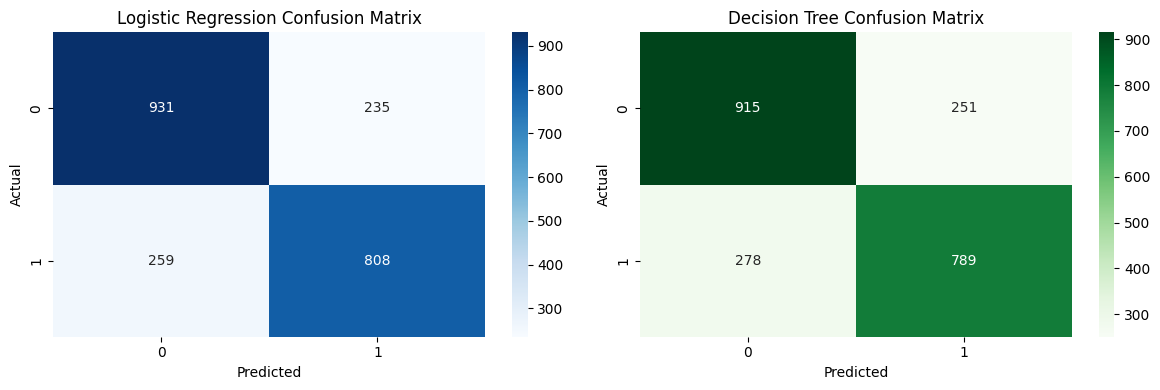

In [10]:
# Model Evaluation

# Predictions
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("=== Model Accuracy ===")
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_accuracy*100:.2f}%")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, dt_pred), 
            annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print("\nConfusion Matrix saved! ✅")
plt.show()

Business Insights saved! ✅


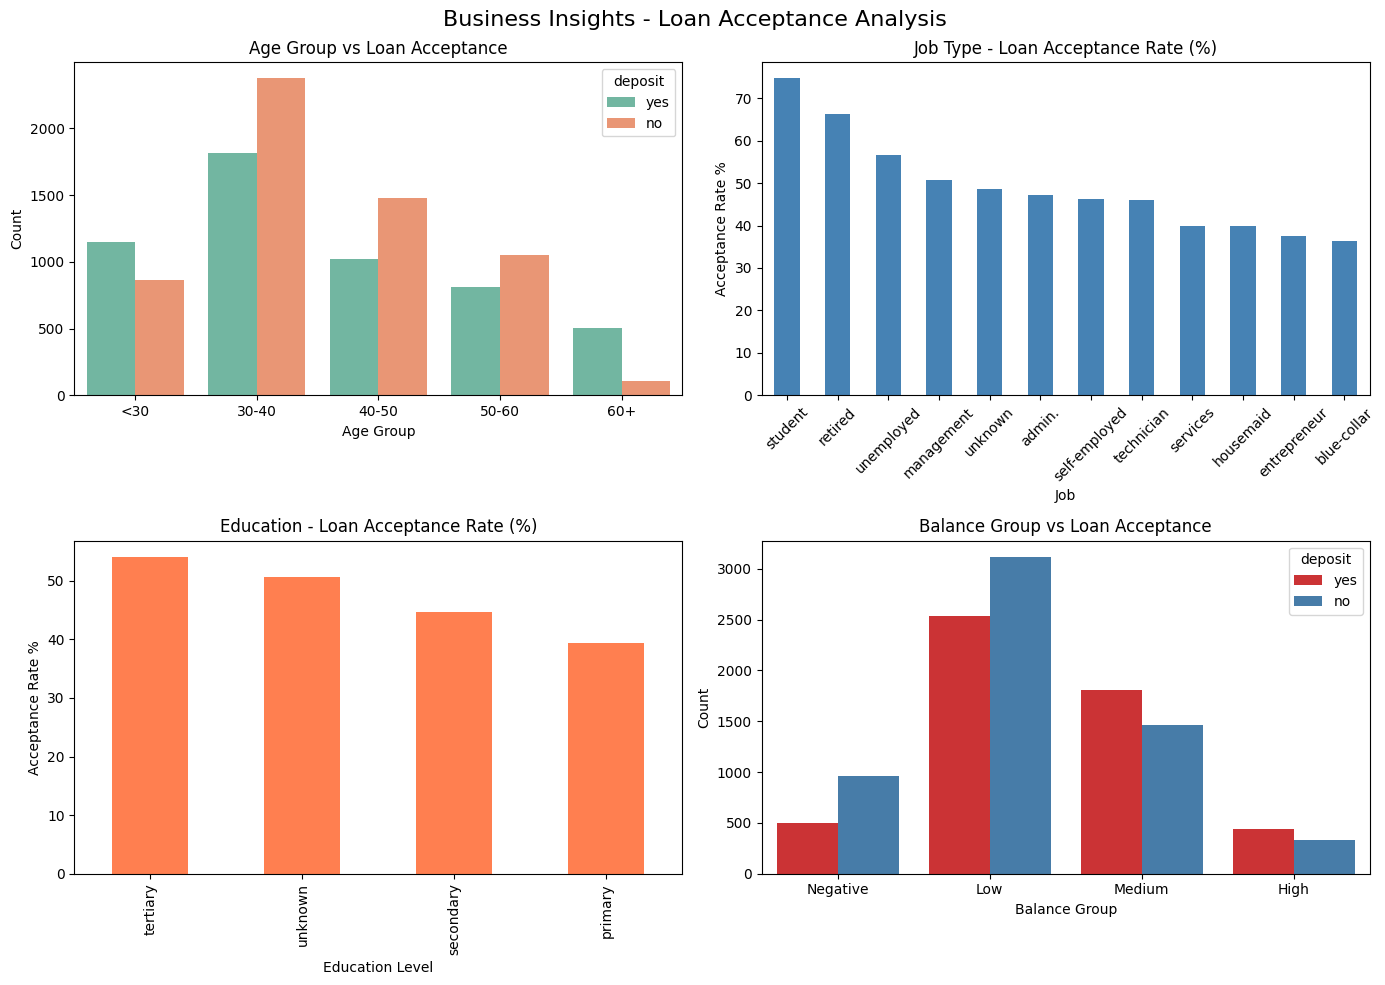

In [11]:
# Business Insights - Kaun se customers loan accept karte hain?

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Business Insights - Loan Acceptance Analysis', fontsize=16)

# Insight 1 - Age Group Analysis
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 30, 40, 50, 60, 100], 
                          labels=['<30', '30-40', '40-50', '50-60', '60+'])
sns.countplot(x='age_group', hue='deposit', data=df, palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Age Group vs Loan Acceptance')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Count')

# Insight 2 - Job vs Loan Acceptance Rate
job_deposit = df.groupby('job')['deposit'].apply(
              lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
job_deposit.plot(kind='bar', color='steelblue', ax=axes[0,1])
axes[0,1].set_title('Job Type - Loan Acceptance Rate (%)')
axes[0,1].set_xlabel('Job')
axes[0,1].set_ylabel('Acceptance Rate %')
axes[0,1].tick_params(axis='x', rotation=45)

# Insight 3 - Education vs Loan Acceptance Rate
edu_deposit = df.groupby('education')['deposit'].apply(
              lambda x: (x=='yes').sum()/len(x)*100).sort_values(ascending=False)
edu_deposit.plot(kind='bar', color='coral', ax=axes[1,0])
axes[1,0].set_title('Education - Loan Acceptance Rate (%)')
axes[1,0].set_xlabel('Education Level')
axes[1,0].set_ylabel('Acceptance Rate %')

# Insight 4 - Balance Group vs Loan Acceptance
df['balance_group'] = pd.cut(df['balance'], 
                              bins=[-10000, 0, 1000, 5000, 100000], 
                              labels=['Negative', 'Low', 'Medium', 'High'])
sns.countplot(x='balance_group', hue='deposit', data=df, palette='Set1', ax=axes[1,1])
axes[1,1].set_title('Balance Group vs Loan Acceptance')
axes[1,1].set_xlabel('Balance Group')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('business_insights.png', dpi=150, bbox_inches='tight')
print("Business Insights saved! ✅")
plt.show()

## Conclusion

### Key Findings:
- Students and Retired customers are most likely to accept loan offers
- Customers with Tertiary education have higher acceptance rates
- Customers aged 60+ show highest loan acceptance
- Medium to High balance customers accept more loans
- Decision Tree performed better than Logistic Regression

### Business Recommendation:
Bank should target Students, Retired persons, and
customers with higher education for loan offers.